# Train Router (for LoRAs on mix of 3 datasets)

Notebook-first pipeline with safety gates:

- dependency checks
- optional FiftyOne export + manifest generation
- one-batch shape/loss sanity
- mandatory pilot before full run


In [1]:
from __future__ import annotations

import random
import sys
from pathlib import Path

import numpy as np
import torch

# if things fail, comment next four rows 
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / '.git').exists():
            return candidate
    return start


REPO_ROOT = find_repo_root(Path.cwd().resolve())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# fix new pyTorch issue
from pipelines.training import EpochMetrics
torch.serialization.add_safe_globals([EpochMetrics])

RUN_MODE = 'full'  # pilot | full
PREPARE_DATA = False
AUTO_CONFIRM_FULL = True

print('Repo root:', REPO_ROOT)
print('Run mode:', RUN_MODE)


Repo root: /teamspace/studios/this_studio/Hot-Peppers-Company-Computer-Vision
Run mode: full


In [2]:
CONFIG_PATH = REPO_ROOT / 'configs/training/moe_mambavis_day_night_adverse.yaml'
CONFIG_PATH

PosixPath('/teamspace/studios/this_studio/Hot-Peppers-Company-Computer-Vision/configs/training/moe_mambavis_day_night_adverse.yaml')

In [3]:
import gc
import torch

# Delete huge variables from the previous run
if 'model' in locals(): del model
if 'optimizer' in locals(): del optimizer
if 'train_loader' in locals(): del train_loader
if 'val_loader' in locals(): del val_loader

# Force Python garbage collection
gc.collect()

# Force PyTorch to empty the GPU cache
torch.cuda.empty_cache()

print("GPU Memory Cleared!")


GPU Memory Cleared!


In [4]:
from pipelines.dependencies import check_packages, assert_required_packages

required = ['torch', 'torchvision', 'yaml', 'safetensors', 'tqdm', 'einops']
optional = ['fiftyone', 'mambavision', 'wandb']
status = check_packages(required + optional)
status


{'torch': True,
 'torchvision': True,
 'yaml': True,
 'safetensors': True,
 'tqdm': True,
 'einops': True,
 'fiftyone': True,
 'mambavision': True,
 'wandb': True}

In [5]:
assert_required_packages(['torch', 'torchvision', 'yaml', 'safetensors', 'einops'])
print('Core dependencies look good')


Core dependencies look good


In [6]:
from pipelines.contracts import TrainConfig

cfg = TrainConfig.from_yaml(CONFIG_PATH)

cfg.model.model_file = str((REPO_ROOT / cfg.model.model_file).resolve())
cfg.ckpt.output_path = str((REPO_ROOT / cfg.ckpt.output_path).resolve())

if cfg.model.base_checkpoint:
    cfg.model.base_checkpoint = str((REPO_ROOT / cfg.model.base_checkpoint).resolve())

if cfg.data.get('lora_output_path'):
    cfg.data['lora_output_path'] = str((REPO_ROOT / cfg.data['lora_output_path']).resolve())
    
if cfg.model.moe_model_file:
    cfg.model.moe_model_file = str((REPO_ROOT / 'mamba-vision-ours/moe_model.py').resolve())

if cfg.model.moe_adapters:
    cfg.model.moe_adapters = {
            domain: str((REPO_ROOT / path).resolve())
            for domain, path in cfg.model.moe_adapters.items()
        }

if cfg.model.moe_router_weights:
    cfg.model.moe_router_weights = str((REPO_ROOT / cfg.model.moe_router_weights).resolve())

cfg

TrainConfig(run_name='moe_mambavis_day_night_adverse_blanket', data={'source': 'fiftyone_zoo_or_local', 'zoo_name': 'acdc', 'split_train': 'train', 'split_val': 'validation', 'time_of_day': None, 'manifest_train': 'configs/manifests/acdc_train.json', 'manifest_val': 'configs/manifests/acdc_val.json', 'export_train_dir': 'data/exports/acdc/train', 'export_val_dir': 'data/exports/acdc/val', 'max_samples_train': None, 'max_samples_val': None, 'local_dataset_dir': '/teamspace/studios/this_studio/datasets/acdc/acdc', 'local_dataset_type': 'COCODetectionDataset', 'lora_output_path': '/teamspace/studios/this_studio/Hot-Peppers-Company-Computer-Vision/checkpoints/lora/acdc_adverse.safetensors'}, model=ModelSection(backbone='mamba_vision_T2', num_classes=8, pretrained=False, checkpoint_path='', base_checkpoint='/teamspace/studios/this_studio/Hot-Peppers-Company-Computer-Vision/checkpoints/base/coco_base_epoch009.ckpt', moe_router_weights='/teamspace/studios/this_studio/Hot-Peppers-Company-Compu

In [7]:

from pipelines.model_loader import create_model_from_config
from pipelines.training import load_checkpoint, resolve_device

device = resolve_device(cfg.train.device)
moe_model = create_model_from_config(cfg.model, device=str(device)).to(device)

print(f'MoE model created with route for device={device}')

MoE configuration detected. Wrapping base model...
Loading checkpoint for domain 'day' from /teamspace/studios/this_studio/Hot-Peppers-Company-Computer-Vision/checkpoints/lora/bdd_day_train_blanket_epoch007.ckpt
Loading checkpoint for domain 'night' from /teamspace/studios/this_studio/Hot-Peppers-Company-Computer-Vision/checkpoints/lora/bdd_night_train_blanket_epoch007.ckpt
Loading checkpoint for domain 'adverse' from /teamspace/studios/this_studio/Hot-Peppers-Company-Computer-Vision/checkpoints/lora/acdc_train_blanket_epoch012.ckpt
Detected LoRA rank: 8
MoE model created with route for device=cuda


In [8]:
for p in moe_model.parameters():
    p.requires_grad = False

for p in moe_model.router.parameters():
    p.requires_grad = True

print('Frozen all except router. Trainable params:', sum(p.numel() for p in moe_model.parameters() if p.requires_grad))

Frozen all except router. Trainable params: 4931


In [9]:
from torch.utils.data import ConcatDataset, TensorDataset, Dataset, DataLoader
from pipelines.contracts import DatasetManifest
from pipelines.coco_dataset import build_dataloader

# Load manifests for each domain
day_manifest = DatasetManifest.from_json(REPO_ROOT / 'configs/manifests/bdd_day_train.json')
night_manifest = DatasetManifest.from_json(REPO_ROOT / 'configs/manifests/bdd_night_train.json')
adverse_manifest = DatasetManifest.from_json(REPO_ROOT / 'configs/manifests/acdc_train.json')

# Create datasets with labels
day_dataset = build_dataloader(day_manifest, image_size=cfg.train.image_size, batch_size=1, num_workers=16, shuffle=False, max_samples=10000)
night_dataset = build_dataloader(night_manifest, image_size=cfg.train.image_size, batch_size=1, num_workers=16, shuffle=False, max_samples=10000)
adverse_dataset = build_dataloader(adverse_manifest, image_size=cfg.train.image_size, batch_size=1, num_workers=16, shuffle=False, max_samples=10000)


# Concatenate datasets
base_concat = ConcatDataset([
    day_dataset.dataset,
    night_dataset.dataset,
    adverse_dataset.dataset,
])

# Build labels aligned with that concatenation
labels = torch.cat([
    torch.zeros(len(day_dataset.dataset), dtype=torch.long),
    torch.ones(len(night_dataset.dataset), dtype=torch.long),
    torch.full((len(adverse_dataset.dataset),), 2, dtype=torch.long),
])

assert len(base_concat) == len(labels)

# Wrap into a labeled dataset
class RouterDataset(Dataset):
    def __init__(self, base_ds, labels):
        self.base_ds = base_ds
        self.labels = labels

    def __len__(self):
        return len(self.base_ds)

    def __getitem__(self, idx):
        sample = self.base_ds[idx]   # whatever your coco_dataset returns: (image, target, ...)
        if isinstance(sample, (list, tuple)):
            image = sample[0]        # adjust if your dataloader returns something else
        else:
            image = sample
        label = self.labels[idx]
        return image, label

router_dataset = RouterDataset(base_concat, labels)

# DataLoader
router_loader = DataLoader(
    router_dataset,
    batch_size=cfg.train.batch_size,
    shuffle=True,
    num_workers=16,
)

print('Router dataset size:', len(router_dataset))


Router dataset size: 22800


Batch shapes: torch.Size([32, 3, 640, 640]) torch.Size([32])


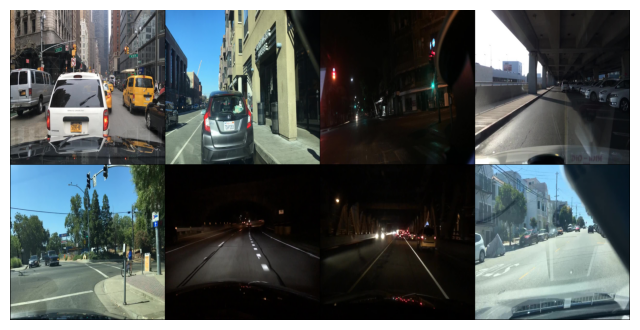

Labels for shown images: [0, 0, 1, 0, 0, 1, 1, 0]

 CHecking boundaries of datasets
0 → label 0
9999 → label 0
10000 → label 1
19999 → label 1
22799 → label 2


In [10]:
import matplotlib.pyplot as plt
import torchvision

# one batch
images, labels = next(iter(router_loader))
print("Batch shapes:", images.shape, labels.shape)

# grid of first 8 images
grid = torchvision.utils.make_grid(images[:8], nrow=4, normalize=True)
plt.figure(figsize=(8, 6))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis("off")
plt.show()

print("Labels for shown images:", labels[:8].tolist())  # expect 0/1/2 mapping day/night/adverse


print("\n CHecking boundaries of datasets")
# indices around transitions
for idx in [0, len(day_dataset.dataset)-1,
            len(day_dataset.dataset),
            len(day_dataset.dataset)+len(night_dataset.dataset)-1,
            len(router_dataset)-1]:
    img, lbl = router_dataset[idx]
    print(idx, "→ label", lbl.item())


In [11]:
optimizer = torch.optim.AdamW(moe_model.router.parameters(), lr=cfg.train.lr, weight_decay=cfg.train.weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.train.epochs)

print('Optimizer and scheduler set up')

Optimizer and scheduler set up


In [12]:
from tqdm import tqdm
import torch.nn.functional as F
def _image_stats(images: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    # images: (B,3,H,W), on-device
    x = images.float()
    if x.max() > 2.0:
        x = x / 255.0

    # brightness (mean over C,H,W)
    brightness = x.mean(dim=(1, 2, 3))

    # contrast (std over C,H,W)
    contrast = x.std(dim=(1, 2, 3))

    # saturation: (max-min)/(max+eps) per pixel, then mean
    mx = x.max(dim=1)[0]
    mi = x.min(dim=1)[0]
    saturation = ((mx - mi) / (mx + eps)).mean(dim=(1, 2))

    # high-frequency energy – Laplacian variance per image
    B, C, H, W = x.shape
    device = x.device
    kernel = torch.tensor(
        [[0.0, 1.0, 0.0],
         [1.0, -4.0, 1.0],
         [0.0, 1.0, 0.0]],
        device=device, dtype=x.dtype,
    )
    # shape: (C,1,3,3) for depthwise conv
    kernel = kernel.view(1, 1, 3, 3).repeat(C, 1, 1, 1)

    # depthwise conv over original (B,C,H,W)
    hf = F.conv2d(x, kernel, padding=1, groups=C)   # <— no reshape, groups=C is correct
    hf_energy = hf.var(dim=(1, 2, 3))

    return torch.stack([brightness, 
                        contrast, 
                        hf_energy, 
                        saturation], dim=1)

# 1. Pre-extract all stats
print("Precomputing image stats once to bypass disk I/O...")
all_stats = []
all_labels = []

moe_model.router.eval()
with torch.no_grad():
    # Only iterate through the slow disk loader ONCE
    for images, labels in tqdm(router_loader, desc="Caching stats"):
        images = images.to(device)
        # Assuming you pull _image_stats out or call it directly:
        stats = _image_stats(images) 
        all_stats.append(stats.cpu())
        all_labels.append(labels.cpu())

# Convert to single tensors
X_train = torch.cat(all_stats, dim=0)
Y_train = torch.cat(all_labels, dim=0)

# Create a blazingly fast RAM-only dataloader
from torch.utils.data import TensorDataset

fast_dataset = TensorDataset(X_train, Y_train)
fast_loader = torch.utils.data.DataLoader(
    fast_dataset, 
    batch_size=256, 
    shuffle=True
)

# 2. Now train your MLP on the fast dataloader
print("Starting real training loop...")
moe_model.router.train()
moe_model.router.to(device)


# balance weights -> since acdc is small, we penalize incorrect guesses for it more
class_weights = torch.tensor([1.0, 1.0, 10000.0 / 2800.0]).to(device)

for epoch in range(cfg.train.epochs):
    epoch_loss = 0.0
    correct, total = 0, 0
    
    # This will now take ~1 second per epoch!
    for stats, labels in fast_loader:
        stats, labels = stats.to(device), labels.to(device)
        
        optimizer.zero_grad()

        logits = moe_model.router.train_cross_entropy_loss(stats) 
        
        loss = F.cross_entropy(logits, labels, weight=class_weights)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        # first batch's predictions to see if it's outputting the same class
        if total == labels.size(0):
            print(f"Sample preds: {preds[:10].tolist()}")
            print(f"Sample trues: {labels[:10].tolist()}")
        
    print(f'Epoch {epoch+1}: Loss = {epoch_loss/len(fast_loader):.4f}, Acc = {correct/total:.4f}')


Precomputing image stats once to bypass disk I/O...


Caching stats:   0%|          | 0/713 [00:00<?, ?it/s]

Caching stats: 100%|██████████| 713/713 [03:09<00:00,  3.76it/s]


Starting real training loop...
Sample preds: [2, 1, 2, 1, 0, 1, 0, 2, 0, 2]
Sample trues: [2, 1, 2, 1, 0, 1, 0, 1, 0, 2]
Epoch 1: Loss = 0.2705, Acc = 0.9186
Sample preds: [1, 1, 1, 0, 2, 1, 1, 0, 0, 1]
Sample trues: [1, 1, 1, 0, 1, 1, 1, 0, 0, 1]
Epoch 2: Loss = 0.2760, Acc = 0.9157
Sample preds: [1, 2, 1, 2, 0, 1, 1, 0, 1, 0]
Sample trues: [1, 2, 1, 2, 1, 1, 1, 0, 1, 0]
Epoch 3: Loss = 0.2729, Acc = 0.9194
Sample preds: [0, 0, 0, 0, 2, 0, 0, 1, 2, 1]
Sample trues: [0, 0, 0, 0, 2, 0, 0, 1, 2, 1]
Epoch 4: Loss = 0.2686, Acc = 0.9200
Sample preds: [1, 1, 0, 1, 2, 0, 1, 1, 1, 1]
Sample trues: [2, 1, 0, 2, 1, 0, 1, 1, 1, 1]
Epoch 5: Loss = 0.2635, Acc = 0.9207
Sample preds: [0, 0, 0, 0, 0, 0, 0, 2, 1, 0]
Sample trues: [0, 0, 0, 0, 0, 0, 0, 1, 1, 0]
Epoch 6: Loss = 0.2662, Acc = 0.9223
Sample preds: [1, 0, 1, 2, 1, 1, 1, 0, 0, 1]
Sample trues: [1, 0, 1, 2, 1, 1, 1, 0, 0, 1]
Epoch 7: Loss = 0.2625, Acc = 0.9204
Sample preds: [0, 1, 1, 1, 0, 2, 2, 0, 0, 2]
Sample trues: [0, 1, 1, 1, 0, 0, 2,

In [13]:
router_ckpt_path = getattr(cfg.model, 'moe_router_weights', 'checkpoints/router/router_v1.pt')
router_ckpt_path = REPO_ROOT / router_ckpt_path
router_ckpt_path.parent.mkdir(parents=True, exist_ok=True)
torch.save(moe_model.router.state_dict(), str(router_ckpt_path))
print('Saved router weights to:', router_ckpt_path)

Saved router weights to: /teamspace/studios/this_studio/Hot-Peppers-Company-Computer-Vision/checkpoints/router/router_v1.ckpt


In [14]:
moe_model.router.eval()
with torch.no_grad():
    images, labels = next(iter(router_loader))
    images, labels = images[:4].to(device), labels[:4].to(device)
    logits = moe_model.router(images)
    probs = F.softmax(logits, dim=1)
    print('Logits shape:', logits.shape)
    print('Sample probs:', probs[:2].cpu().numpy())
    print('Sample labels:', labels[:2].cpu().numpy())

Logits shape: torch.Size([4, 3])
Sample probs: [[0.414982   0.23233822 0.35267976]
 [0.5704929  0.21372773 0.21577936]]
Sample labels: [2 0]
